# Data Mining — DBSCAN Practice

## Purpose

In this practice, you will use **DBSCAN** to detect unusual credit card transactions. The method is **unsupervised**: the algorithm will not use the fraud label during training. The label `Class` will be used only at the end to evaluate whether the points marked as noise are related to actual fraud cases.

## Learning goals

By the end of the activity, you should be able to:

- Explain how DBSCAN uses density to form clusters and detect noise.
- Prepare a numerical dataset for a distance-based algorithm.
- Select tentative DBSCAN parameters using a k-distance plot.
- Treat DBSCAN noise points as possible anomalies.
- Evaluate anomaly flags against known labels using precision, recall, F1-score, and a confusion matrix.

## DBSCAN in one page

**DBSCAN** stands for *Density-Based Spatial Clustering of Applications with Noise*. It groups observations that are close to many other observations and marks isolated observations as noise. In anomaly detection, those noise points are treated as candidates for unusual behavior.

### Main parameters

- **eps**: neighborhood radius. Two points are neighbors if their distance is at most `eps`.
- **min_samples**: minimum number of observations required to form a dense region.
- **Metric**: distance function used by DBSCAN. In this activity, use Euclidean distance after scaling.

### Relationship schema

```
Scaled transaction vector
        │
        ▼
  eps-neighborhood (distance radius)
        │
        ▼
   neighbors ≥ min_samples?
    ┌───┴───┐
   yes      no
    │        │
    ▼        ▼
Core point   within eps of a core point?
(starts or    ┌───┴───┐
 expands      yes     no
 cluster)      │       │
    │          ▼       ▼
    │    Border point  Noise point (label -1)
    │    (belongs to   → Possible anomaly /
    │     a cluster)     candidate fraud alert
    └──────────┘
```

### Important interpretation rule

> A DBSCAN noise point is **not** automatically a fraudulent transaction. It only means that the transaction is located in a low-density region of the feature space. The business interpretation is: this transaction deserves attention because it does not look similar to most transactions in the sample.


## 1. Setup and dataset access — 10 pts

> **Listo:** `creditcard.csv` ya está descargado en esta carpeta. Puedes ir directo a la sección 2.

### Dataset

Use the **Credit Card Fraud Detection** dataset from Kaggle:

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

The file you need is `creditcard.csv`. It contains anonymized numerical features `V1` to `V28`, `Time`, `Amount`, and `Class`. The target label is `Class`, where **1** means fraud and **0** means legitimate.

### Option A: Google Colab

Upload your Kaggle API token `kaggle.json` to Colab and run:


In [ ]:
!pip install -q kaggle
from google.colab import files
files.upload()  # Upload kaggle.json
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip


### Option B: Local computer

Run these commands from the terminal after downloading `kaggle.json` from your Kaggle account:

```bash
python -m venv dbscan-env
source dbscan-env/bin/activate          # macOS/Linux
# dbscan-env\Scripts\activate         # Windows PowerShell

pip install pandas numpy matplotlib scikit-learn kaggle

mkdir -p ~/.kaggle
cp kaggle.json ~/.kaggle/
chmod 600 ~/.kaggle/kaggle.json
kaggle datasets download -d mlg-ulb/creditcardfraud
unzip -o creditcardfraud.zip
```

### Grading evidence — 10 pts

- **4 pts**: The notebook imports all required libraries without errors.
- **4 pts**: The file `creditcard.csv` is loaded successfully.
- **2 pts**: The dataset shape and first rows are displayed.


## 2. Data loading and first inspection — 15 pts

Run the following cell. Keep the output visible in your notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("creditcard.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Check the expected columns and the target distribution.


In [2]:
expected_columns = {"Time", "Amount", "Class"} | {f"V{i}" for i in range(1, 29)}
missing_columns = expected_columns - set(df.columns)

print("Missing expected columns:", missing_columns)
print("\nClass counts:")
print(df["Class"].value_counts().sort_index())
print("\nClass percentage:")
print(df["Class"].value_counts(normalize=True).sort_index().mul(100).round(4))

assert len(missing_columns) == 0, "Some expected columns are missing."
assert df["Class"].isin([0, 1]).all(), "Class must contain only 0 and 1."


Missing expected columns: set()

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentage:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


Inspect missing values and basic statistics for `Time`, `Amount`, and `Class`.


In [3]:
missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary.head(10))
display(df[["Time", "Amount", "Class"]].describe().T)
display(df.groupby("Class")["Amount"].describe())


Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.500,172792.00
Amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16
Class,284807.0,0.001727,0.041527,0.0,0.0,0.0,0.000,1.00


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


Create two simple plots.


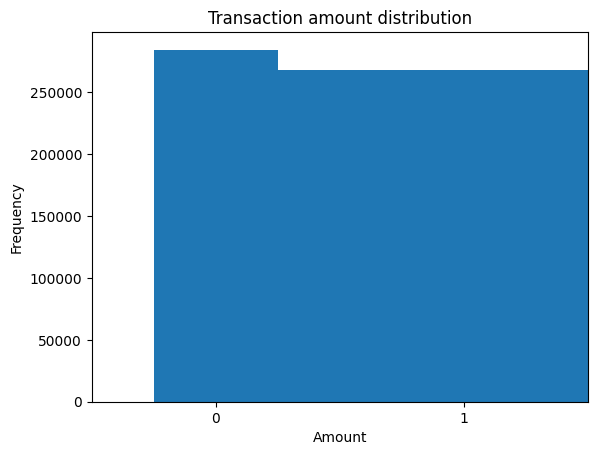

In [4]:
ax = df["Class"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Class distribution")
ax.set_xlabel("Class: 0 = legitimate, 1 = fraud")
ax.set_ylabel("Number of transactions")
plt.show()

ax = df["Amount"].plot(kind="hist", bins=80)
ax.set_title("Transaction amount distribution")
ax.set_xlabel("Amount")
plt.show()


### Grading evidence — 15 pts

- **5 pts**: Column validation and class distribution are shown.
- **4 pts**: Missing value check is included.
- **4 pts**: Descriptive statistics are displayed.
- **2 pts**: Two basic plots are included.


## 3. Feature preparation — 15 pts

DBSCAN is distance-based. Features with larger scales can dominate the distance calculation, so all input variables must be **scaled**. The label `Class` must **not** be included in the DBSCAN input matrix.

For classroom efficiency, use a guided subset that contains all fraud cases and a sample of legitimate transactions. This keeps the runtime manageable and gives enough fraud cases for evaluation. The label is used only to build an educational subset and later evaluate the result; it is **not** used by DBSCAN during fitting.


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RANDOM_STATE = 42
N_NORMAL = 2000

normal_df = df[df["Class"] == 0].sample(n=N_NORMAL, random_state=RANDOM_STATE)
fraud_df = df[df["Class"] == 1]
work_df = (
    pd.concat([normal_df, fraud_df], axis=0)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print("Working dataset shape:", work_df.shape)
print(work_df["Class"].value_counts().sort_index())


Working dataset shape: (2492, 31)
Class
0    2000
1     492
Name: count, dtype: int64


Build the input matrix, scale it, and create the lower-dimensional modeling matrix used by DBSCAN.


In [6]:
feature_cols = [col for col in work_df.columns if col != "Class"]
X = work_df[feature_cols].copy()
y = work_df["Class"].astype(int).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Input matrix shape:", X_scaled.shape)
print("Number of labels stored for evaluation:", y.shape[0])


Input matrix shape: (2492, 30)
Number of labels stored for evaluation: 2492


Create a two-dimensional PCA projection **only for visualization**. DBSCAN will be fitted on a **10-dimensional** PCA modeling matrix created from the scaled features. This keeps the practice computationally manageable and reduces the effect of high-dimensional distance concentration.


Modeling matrix shape: (2492, 10)
Explained variance in 10 components: 0.7589


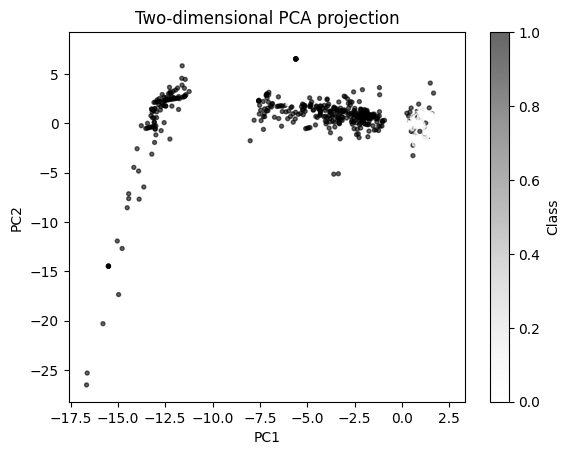

In [7]:
pca_model = PCA(n_components=10, random_state=RANDOM_STATE)
X_model = pca_model.fit_transform(X_scaled)

print("Modeling matrix shape:", X_model.shape)
print("Explained variance in 10 components:", round(pca_model.explained_variance_ratio_.sum(), 4))

pca_df = pd.DataFrame(X_model[:, :2], columns=["PC1", "PC2"])
pca_df["Class"] = y.values

ax = pca_df.plot(kind="scatter", x="PC1", y="PC2", c="Class", s=8, alpha=0.6)
ax.set_title("Two-dimensional PCA projection")
plt.show()


### Grading evidence — 15 pts

- **5 pts**: The working subset is created correctly.
- **5 pts**: `Class` is excluded from `X` and stored separately as `y`.
- **3 pts**: Standard scaling is applied to all input features.
- **2 pts**: A PCA modeling matrix and 2D visualization are included.


## 4. Choosing DBSCAN parameters — 20 pts

The two key parameters are **eps** and **min_samples**. A common starting point is to set `min_samples` between the number of dimensions and a smaller practical value. For this activity, start with `min_samples = 15` to keep the model interpretable and computationally manageable.

A **k-distance plot** helps you choose a tentative `eps`. For each point, compute the distance to its k-th nearest neighbor. Sort those distances from smallest to largest and look for an elbow or sudden increase.


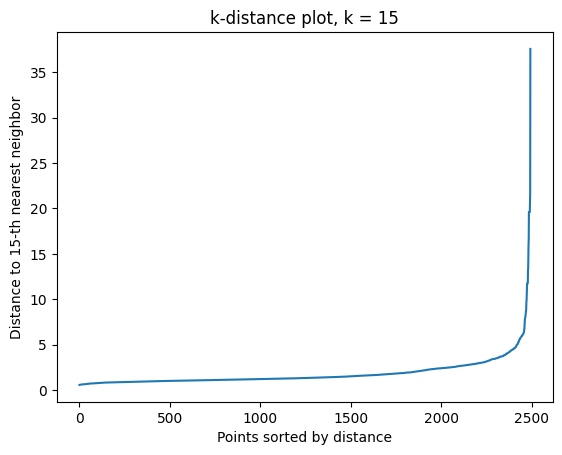

In [8]:
from sklearn.neighbors import NearestNeighbors

min_samples = 15
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_model)
distances, indices = neighbors.kneighbors(X_model)
k_distances = np.sort(distances[:, -1])

ax = pd.Series(k_distances).plot()
ax.set_title(f"k-distance plot, k = {min_samples}")
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.show()


Zoom into the upper tail of the plot, where the elbow is usually easier to see.


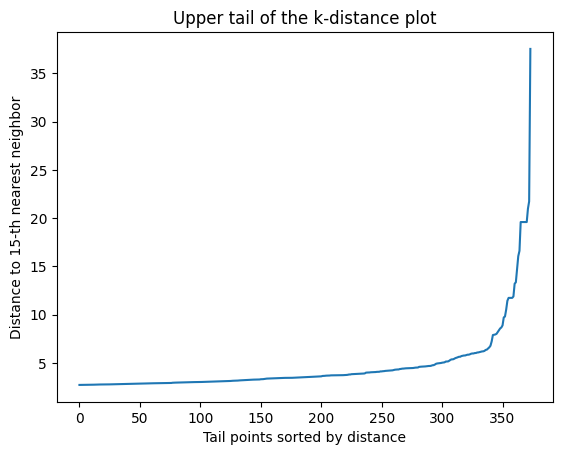

In [9]:
tail_start = int(0.85 * len(k_distances))
ax = pd.Series(k_distances[tail_start:]).reset_index(drop=True).plot()
ax.set_title("Upper tail of the k-distance plot")
ax.set_xlabel("Tail points sorted by distance")
ax.set_ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.show()


In [10]:
print("Useful percentiles for eps exploration:")
for q in [85, 90, 92, 95, 97, 99]:
    print(q, np.percentile(k_distances, q).round(4))


Useful percentiles for eps exploration:
85 2.7044
90 3.1067
92 3.4395
95 4.0853
97 4.9622
99 8.5688


Use the plot and percentiles to set a starting value. If the model returns almost no noise points, **reduce** `eps`. If it returns almost every point as noise, **increase** `eps`.


In [11]:
chosen_eps = 3.5  # Replace this value after reviewing your k-distance plot.
print("Chosen eps:", chosen_eps)
print("Chosen min_samples:", min_samples)


Chosen eps: 3.5
Chosen min_samples: 15


### Grading evidence — 20 pts

- **7 pts**: The k-distance plot is generated.
- **5 pts**: The upper-tail plot or percentile table is included.
- **5 pts**: A specific `eps` value is selected.
- **3 pts**: The selected `eps` and `min_samples` are stated before fitting DBSCAN.


---

## Tu práctica empieza aquí

Las secciones **1 a 4** ya están ejecutadas. Tienes listas las variables:

- `X_model` — matriz PCA de 10 dimensiones para DBSCAN
- `work_df`, `y`, `pca_df` — datos y etiquetas para evaluar después
- `distances`, `k_distances` — distancias k-NN para análisis
- `chosen_eps`, `min_samples` — parámetros tentativos (ajusta `chosen_eps` si lo necesitas)

A partir de la **sección 5**, completa las celdas tú mismo.


## 5. Fitting DBSCAN and visualizing anomalies — 20 pts

Fit DBSCAN using the PCA modeling matrix. DBSCAN labels noise points as **-1**. Treat those noise points as possible anomalies.


In [ ]:
# TODO: Importa DBSCAN y ajusta el modelo con chosen_eps y min_samples
# from sklearn.cluster import DBSCAN
#
# model = DBSCAN(...)
# labels = model.fit_predict(X_model)
#
# Guarda dbscan_label, is_noise y k_distance en work_df
# Reporta: número de clusters, puntos noise y noise rate


Visualize the model output on the PCA projection.


In [ ]:
# TODO: Visualiza los puntos noise en la proyección PCA (pca_df)


Inspect the observations that look most isolated according to the k-distance value.


In [ ]:
# TODO: Muestra las 15 transacciones más aisladas (mayor k_distance)


Run a small **sensitivity analysis**. This does not replace the k-distance plot; it helps you observe how `eps` changes the number of noise points and the detection metrics.


In [ ]:
# TODO: Análisis de sensibilidad — prueba varios valores de eps
# from sklearn.metrics import precision_score, recall_score, f1_score


### Grading evidence — 20 pts

- **5 pts**: DBSCAN is fitted correctly using scaled features.
- **4 pts**: Noise points are converted into an anomaly flag.
- **4 pts**: Number of clusters, number of noise points, and noise rate are reported.
- **4 pts**: PCA visualization of noise points is included.
- **3 pts**: Sensitivity analysis over several `eps` values is included.


## 6. Evaluation against the fraud label — 15 pts

Use `Class` **only now**. The model has already produced an anomaly flag without seeing the label. Evaluate how often DBSCAN noise points match actual fraud transactions.

> **Note:** `Class` was **not** used during DBSCAN fitting — only for evaluation.


In [ ]:
# TODO: Matriz de confusión y classification_report
# y_pred = work_df["is_noise"].astype(int)


Compute a compact fraud-detection summary.


In [ ]:
# TODO: Resumen compacto de detección de fraude


### Technical interpretation

Complete the following after running the evaluation cells:

1. The selected `eps` and `min_samples` values.
2. The number and percentage of transactions marked as noise.
3. Precision, recall, and F1-score for the fraud class.
4. One sentence explaining why a noise point is not necessarily a fraud case.


*(Write your interpretation here.)*

1. **Parameters:** `eps = ...`, `min_samples = ...`
2. **Noise:** ... transactions (...%)
3. **Fraud class metrics:** precision = ..., recall = ..., F1 = ...
4. **Noise ≠ fraud:** ...


### Grading evidence — 15 pts

- **4 pts**: Confusion matrix is displayed with clear row and column labels.
- **4 pts**: Precision, recall, and F1-score are reported.
- **3 pts**: The compact fraud-detection summary is included.
- **3 pts**: The interpretation text cell includes all requested items.
- **1 pt**: The notebook clearly states that `Class` was not used for DBSCAN fitting.


## 7. Notebook organization and reproducibility — 5 pts

Before submitting, **restart the notebook kernel** and run all cells from the beginning. The notebook must run without manual changes after the dataset file is available.

### Grading evidence — 5 pts

- **2 pts**: Code cells are executed in order and outputs are visible.
- **1 pt**: Variable names are clear and consistent.
- **1 pt**: The notebook includes short markdown explanations before each major step.
- **1 pt**: The final notebook is clean, readable, and does not include unrelated experiments.

---

## Score summary

| Section | Points |
|---|---|
| Setup and dataset access | 10 |
| Data loading and first inspection | 15 |
| Feature preparation | 15 |
| Choosing DBSCAN parameters | 20 |
| Fitting DBSCAN and visualizing anomalies | 20 |
| Evaluation against the fraud label | 15 |
| Notebook organization and reproducibility | 5 |
| **Total** | **100** |

## References

- Ester, M., Kriegel, H.-P., Sander, J., and Xu, X. (1996). *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise.* Proceedings of KDD-96, 226–231.
- Kaggle/ULB. Credit Card Fraud Detection dataset. https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Scikit-learn. DBSCAN documentation. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html
- Porwal, U., and Mukund, S. (2018). *Credit Card Fraud Detection in e-Commerce: An Outlier Detection Approach.* https://arxiv.org/abs/1811.02196
- Niu, X., Wang, L., and Yang, X. (2019). *A Comparison Study of Credit Card Fraud Detection: Supervised versus Unsupervised.* https://arxiv.org/abs/1904.10604
